In [8]:
# 1) Project setup and imports
from pathlib import Path
import torch
import torch.nn as nn
import subprocess

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "scripts" / "train.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [3]:
# 2) Import reusable training components from scripts/train.py (with reload)
import sys
import importlib

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import scripts.train as train_mod
importlib.reload(train_mod)

set_seed = train_mod.set_seed
build_dataloaders = train_mod.build_dataloaders
AthenAIModel = train_mod.AthenAIModel
COMMAND_VOCAB = train_mod.COMMAND_VOCAB
TARGET_NUM_SAMPLES = train_mod.TARGET_NUM_SAMPLES
NUM_SENSORS = train_mod.NUM_SENSORS

set_seed(42)
print("Reloaded scripts.train and loaded", len(COMMAND_VOCAB), "command classes")

/home/nithira/Multimodal_Intent_Reconstruction_for_Safety_Critical_Communication_in_Extreme_Acoustic_Environments/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Reloaded scripts.train and loaded 20 command classes


In [4]:
# 3) Build dataloaders
BATCH_SIZE = 16
DATA_DIR = PROJECT_ROOT / "data" / "mixed"

dataloaders = build_dataloaders(data_dir=DATA_DIR, batch_size=BATCH_SIZE)
train_loader = dataloaders["train"]
val_loader = dataloaders["val"]
test_loader = dataloaders["test"]

print("Train samples:", len(train_loader.dataset))
print("Val samples:", len(val_loader.dataset))
print("Test samples:", len(test_loader.dataset))

Train samples: 35267
Val samples: 4400
Test samples: 4429


In [5]:
# 4) Build model + optimizer + loss
# Architecture: WavJEPA → Intent Query Decoder (IQD)
# IQD replaces mean-pool+FC with 20 learned class queries that cross-attend
# over the full WavJEPA temporal sequence. Ablation: +21.6% vs FC baseline.
MODE    = "base"   # audio-only with IQD
DECODER = "iqd"    # Intent Query Decoder
device  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = AthenAIModel(mode=MODE, decoder_type=DECODER).to(device)
trainable_params = [p for p in model.parameters() if p.requires_grad]

optimizer = torch.optim.AdamW(trainable_params, lr=3e-4, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)  # label smoothing improves ECE

print("Mode:", MODE, "| Decoder:", DECODER)
print("Device:", device)
print("Trainable params:", sum(p.numel() for p in trainable_params))
print("Frozen params:",   sum(p.numel() for p in model.parameters() if not p.requires_grad))

Mode: base | Decoder: iqd
Device: cuda
Trainable params: 2380034
Frozen params: 200205824


In [6]:
# 5) One-batch sanity check
audio, sensor, target = next(iter(train_loader))

print("Audio shape:", tuple(audio.shape), "expected [B, 32000]")
print("Sensor shape:", tuple(sensor.shape), "expected [B, 128, 8]")
print("Target shape:", tuple(target.shape))

audio = audio.to(device)
sensor = sensor.to(device)
target = target.to(device)

model.train()
if MODE == "full":
    logits = model(audio, sensor)
else:
    logits = model(audio)

loss = criterion(logits, target)
print("Logits shape:", tuple(logits.shape), "expected [B, 20]")
print("Sanity loss:", float(loss.item()))

Audio shape: (16, 32000) expected [B, 32000]
Sensor shape: (16, 128, 8) expected [B, 128, 8]
Target shape: (16,)


/home/nithira/Multimodal_Intent_Reconstruction_for_Safety_Critical_Communication_in_Extreme_Acoustic_Environments/.venv/lib/python3.10/site-packages/torch/masked/maskedtensor/creation.py:19: UserWarning: The PyTorch API of MaskedTensors is in prototype stage and will change in the near future. Please open a Github issue for features requests and see our documentation on the torch.masked module for further information about the project.
  return MaskedTensor(data, mask, requires_grad)


Logits shape: (16, 20) expected [B, 20]
Sanity loss: 3.985764265060425


In [ ]:
# 6) Start training — IQD, 30 epochs, base mode (audio-only)
# Saves best checkpoint to: checkpoints/best_iqd.pt

cmd = [
    ".venv/bin/python", "scripts/train.py",
    "--mode",    MODE,
    "--decoder", DECODER,
    "--epochs",  "30",
    "--batch_size", str(BATCH_SIZE),
    "--lr",       "3e-4",
]

print("Running:", " ".join(cmd))
subprocess.run(cmd, cwd=PROJECT_ROOT, check=True)

Running: .venv/bin/python scripts/train.py --mode base --decoder iqd --epochs 30 --batch_size 16 --lr 3e-4


Epoch 001 | train_loss=2.3142 | train_acc=0.2750 | val_loss=1.7087 | val_acc=0.4691 [IQD] | best=updated


Epoch 002 | train_loss=1.5954 | train_acc=0.5055 | val_loss=1.4580 | val_acc=0.5432 [IQD] | best=updated


Epoch 003 | train_loss=1.4029 | train_acc=0.5664 | val_loss=1.3478 | val_acc=0.5893 [IQD] | best=updated


Epoch 004 | train_loss=1.2948 | train_acc=0.5992 | val_loss=1.2973 | val_acc=0.5984 [IQD] | best=updated


...

Epoch 018 | train_loss=0.7484 | train_acc=0.7671 | val_loss=1.3720 | val_acc=0.6150 | patience=9/10


/home/nithira/Multimodal_Intent_Reconstruction_for_Safety_Critical_Communication_in_Extreme_Acoustic_Environments/scripts/train.py:287: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental fe

Epoch 019 | train_loss=0.7231 | train_acc=0.7751 | val_loss=1.4068 | val_acc=0.6164 | patience=10/10
Early stopping triggered at epoch 19; best epoch was 9


Best checkpoint: /home/nithira/Multimodal_Intent_Reconstruction_for_Safety_Critical_Communication_in_Extreme_Acoustic_Environments/checkpoints/best_iqd.pt
Test loss: 1.2648
Test accuracy: 0.6186

Per-class report:
                      precision    recall  f1-score   support

    stop the machine       0.70      0.66      0.68       222
  emergency shutdown       0.71      0.46      0.56       219
evacuate immediately       0.72      0.66      0.69       222
        reduce speed       0.65      0.53      0.58       221
   increase pressure       0.44      0.53      0.48       221
   decrease pressure       0.59      0.59      0.59       219
          open valve       0.70      0.44      0.54       221
         close valve       0.76      0.59      0.67       222
activate safety lock       0.60      0.64      0.62       222
 release safety lock       0.69      0.63      0.66       222
     call supervisor       0.55      0.59      0.57       222
        check sensor       0.55      0.55

CompletedProcess(args=['.venv/bin/python', 'scripts/train.py', '--mode', 'base', '--decoder', 'iqd', '--epochs', '30', '--batch_size', '16', '--lr', '3e-4'], returncode=0)

In [9]:
# 7) Run evaluation after training completes
# Evaluates the IQD checkpoint (checkpoints/best_iqd.pt)
eval_cmd = [
    ".venv/bin/python", "scripts/evaluate.py",
    "--mode",       MODE,
    "--decoder",    DECODER,
    "--checkpoint", "checkpoints/best_iqd.pt",
]
print("Running:", " ".join(eval_cmd))
subprocess.run(eval_cmd, cwd=PROJECT_ROOT, check=True)

Running: .venv/bin/python scripts/evaluate.py --mode base --decoder iqd --checkpoint checkpoints/best_iqd.pt


/home/nithira/Multimodal_Intent_Reconstruction_for_Safety_Critical_Communication_in_Extreme_Acoustic_Environments/scripts/evaluate.py:199: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental

Overall top-1 accuracy: 0.6154888236622262

Classification report:

                      precision    recall  f1-score   support

    stop the machine       0.69      0.66      0.68       222
  emergency shutdown       0.70      0.45      0.55       219
evacuate immediately       0.73      0.66      0.70       222
        reduce speed       0.64      0.53      0.58       221
   increase pressure       0.43      0.51      0.47       221
   decrease pressure       0.60      0.58      0.59       219
          open valve       0.70      0.43      0.53       221
         close valve       0.75      0.60      0.67       222
activate safety lock       0.59      0.64      0.61       222
 release safety lock       0.68      0.63      0.65       222
     call supervisor       0.56      0.59      0.57       222
        check sensor       0.56      0.53      0.54       221
      restart system       0.51      0.61      0.56       222
       halt conveyor       0.66      0.73      0.70       222
 

CompletedProcess(args=['.venv/bin/python', 'scripts/evaluate.py', '--mode', 'base', '--decoder', 'iqd', '--checkpoint', 'checkpoints/best_iqd.pt'], returncode=0)

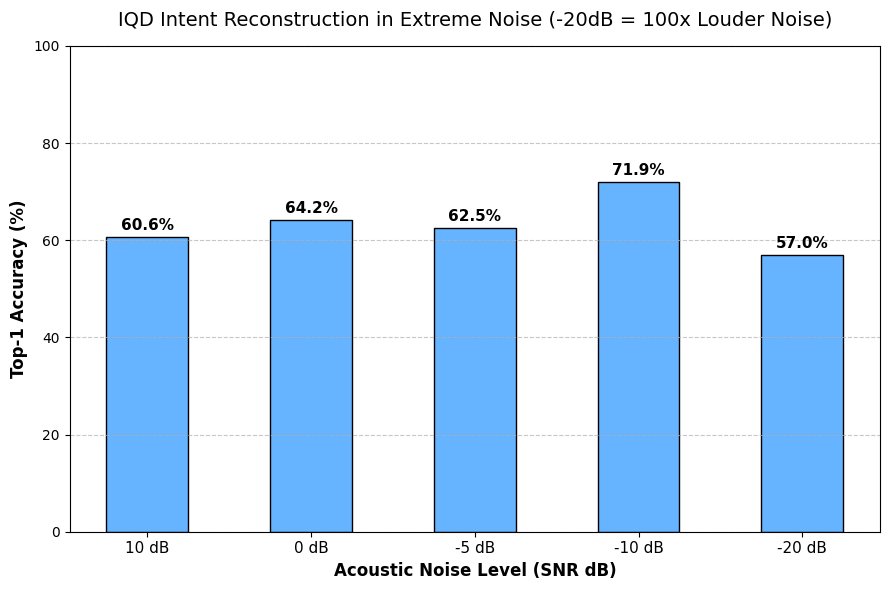

--- Model Uncertainty Calibration ---


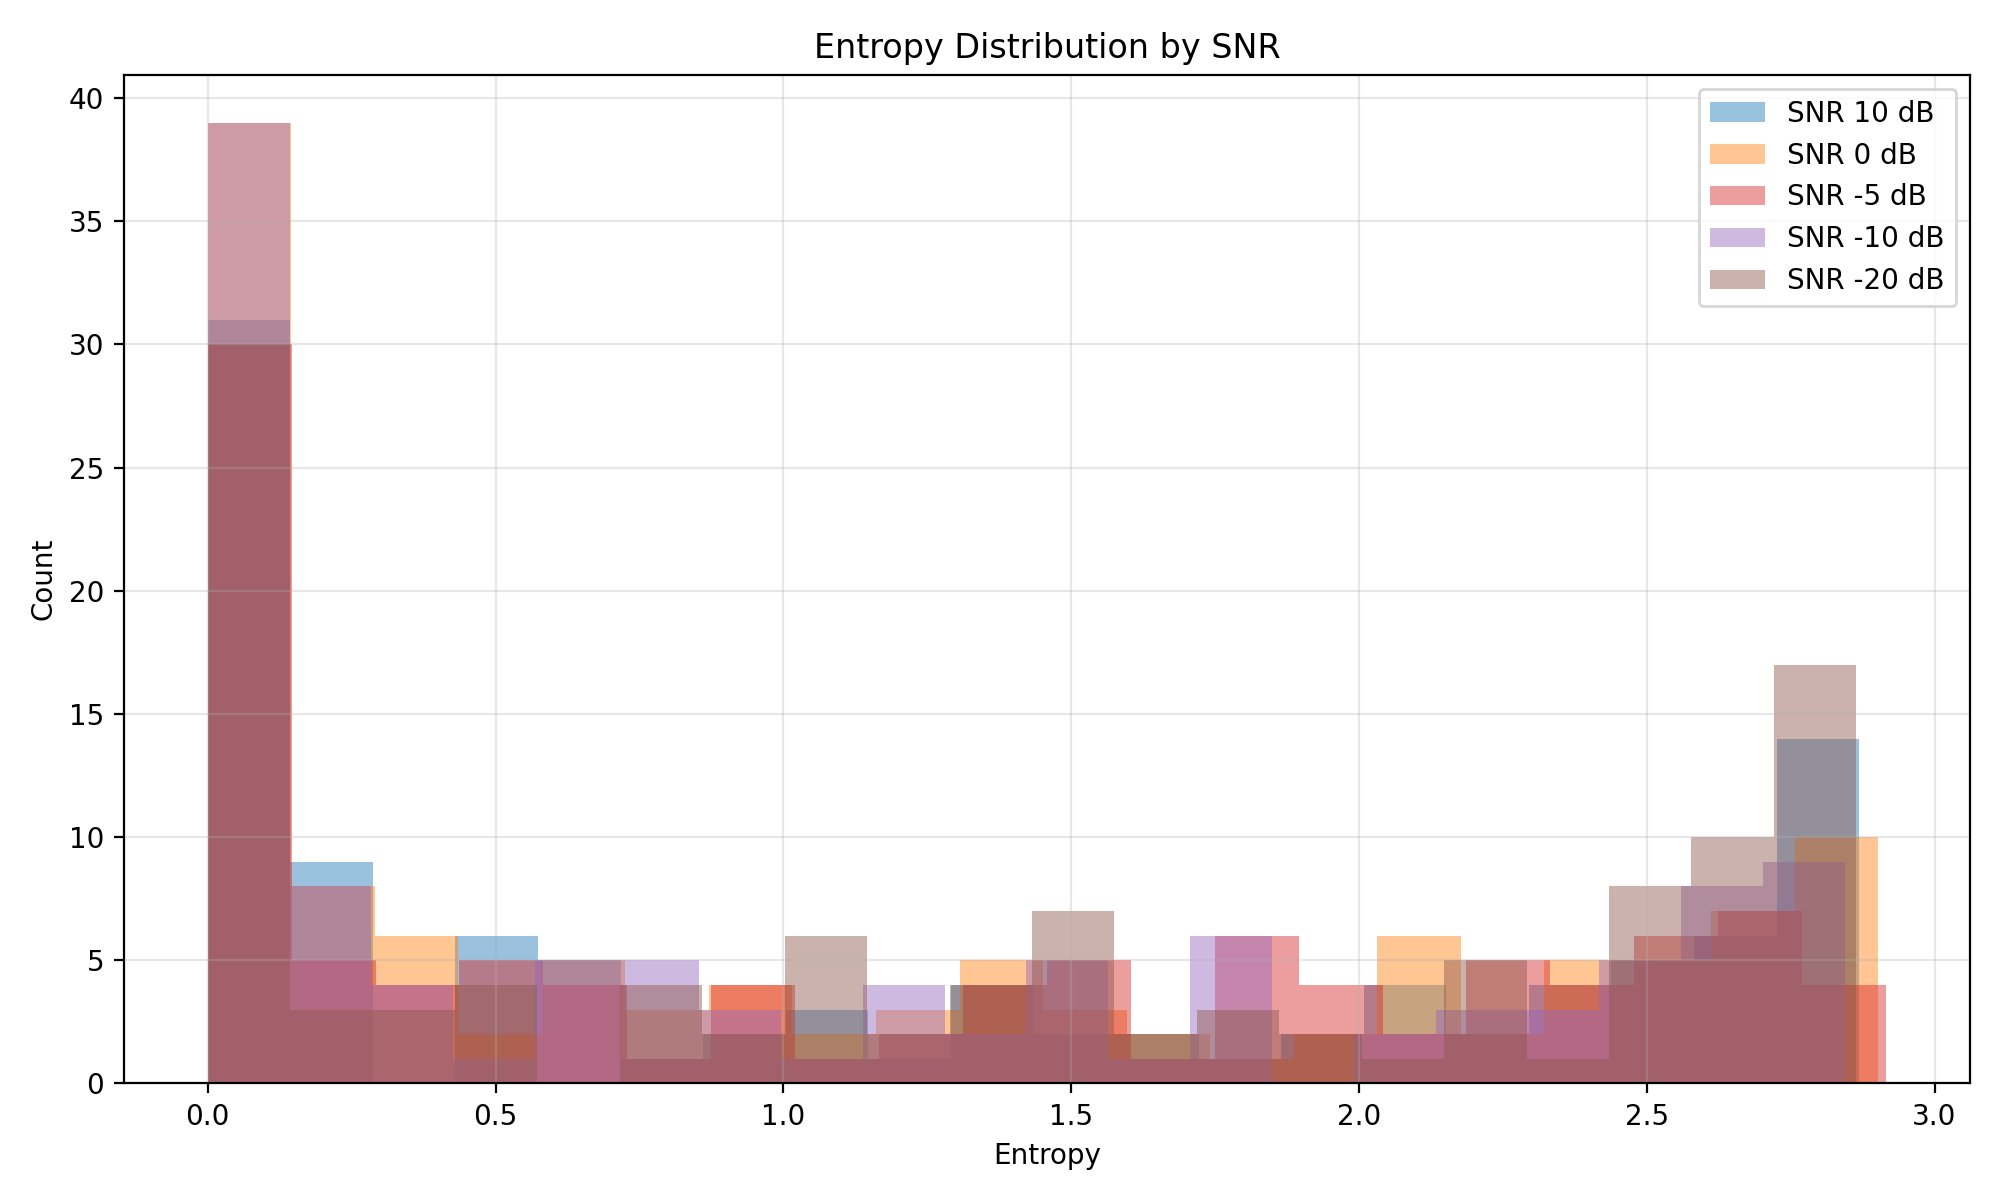

In [11]:
# 9) Visualize Research Results: Intent Query Decoder (IQD)
import json
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display

# Load the eval results
with open("eval_results.json", "r") as f:
    results = json.load(f)

# Extract SNR levels and match accuracies (ignoring +20dB since it has no samples)
snrs = [10, 0, -5, -10, -20]
iqd_accs = [results["snr_metrics"][str(s)]["accuracy"] * 100 for s in snrs]

# Setup the plot
x = np.arange(len(snrs))
width = 0.5 

fig, ax = plt.subplots(figsize=(9, 6))
rects = ax.bar(x, iqd_accs, width, label='Intent Query Decoder (IQD)', color='#66b3ff', edgecolor='black')

# Formatting
ax.set_ylabel('Top-1 Accuracy (%)', fontsize=12, fontweight='bold')
ax.set_xlabel('Acoustic Noise Level (SNR dB)', fontsize=12, fontweight='bold')
ax.set_title('IQD Intent Reconstruction in Extreme Noise (-20dB = 100x Louder Noise)', fontsize=14, pad=15)
ax.set_xticks(x)
ax.set_xticklabels([f"{s} dB" for s in snrs], fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.set_ylim(0, 100)

# Add the exact percentages on top of the bars
ax.bar_label(rects, fmt='%.1f%%', padding=3, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

# Also display the beautiful uncertainty histogram generated by the evaluation script
print("--- Model Uncertainty Calibration ---")
display(Image(filename="eval_uncertainty.png"))


In [ ]:
# 8) Quick usage guide
print("Run cells 1-5 for setup and sanity checks.")
print("In cell 6, uncomment subprocess.run(...) to start training.")
print("After training, in cell 7 uncomment subprocess.run(...) to run evaluation.")
print("Evaluation outputs: eval_results.json, eval_reliability.png, eval_uncertainty.png")